# 03 — Algoritmos Genéticos: ubicación de hospitales

**Curso:** Inteligencia Artificial — Optimización

Usaremos el mismo problema de Hill Climbing y Simulated Annealing:

> Ubicar varios hospitales en una cuadrícula para minimizar la distancia total de las casas al hospital más cercano.

## Objetivos

- representar una solución mediante un cromosoma;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- comparar el mejor individuo y el fitness medio.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

## 1. Problema

Para cada casa $h$, calculamos su distancia al hospital más cercano:

$$
C(H)=
\sum_{h\in\text{casas}}
\min_{p\in H}
d_{\text{Manhattan}}(h,p)
$$

Queremos minimizar $C(H)$.

Como los algoritmos genéticos suelen expresarse como maximización, definimos:

$$
\text{fitness}(H)=-C(H)
$$

Por tanto, un fitness mayor representa una solución de menor costo.

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(
        min(manhattan(house, hospital) for hospital in hospitals)
        for house in houses
    )


def fitness(individual, houses):
    return -total_cost(houses, individual)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        rows, cols = zip(*houses)
        ax.scatter(cols, rows, marker="s", s=110, label="Casas")

    if hospitals:
        rows, cols = zip(*hospitals)
        ax.scatter(cols, rows, marker="P", s=180, label="Hospitales")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f"Costo = {total_cost(houses, hospitals)}")
    plt.tight_layout()
    plt.show()

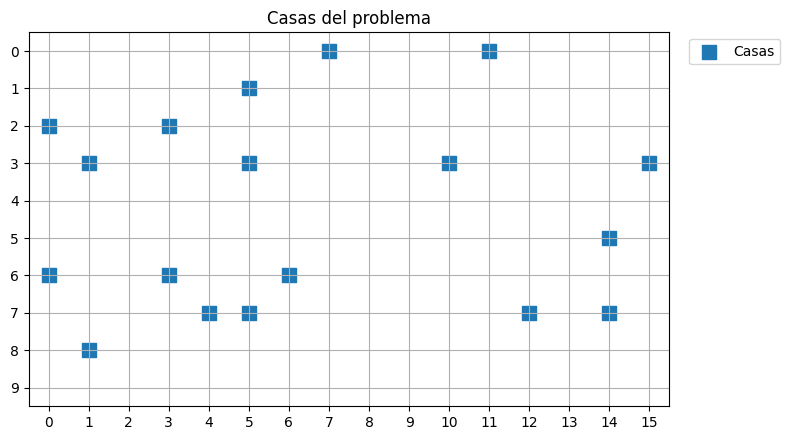

In [3]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [
    (row, col)
    for row in range(HEIGHT)
    for col in range(WIDTH)
]

rng = random.Random(SEED)

houses = set(rng.sample(all_cells, NUM_HOUSES))
valid_hospital_cells = [
    cell for cell in all_cells
    if cell not in houses
]

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    hospitals=[],
    title="Casas del problema",
)

## 2. Representación del cromosoma

Cada individuo contiene las posiciones de los hospitales:

```python
[(fila_1, columna_1), (fila_2, columna_2), (fila_3, columna_3)]
```

Restricciones de la representación:

- ningún hospital puede ubicarse sobre una casa;
- dos hospitales no pueden ocupar la misma celda.

Individuo: [(3, 8), (7, 6), (1, 9)]
Costo: 87
Fitness: -87


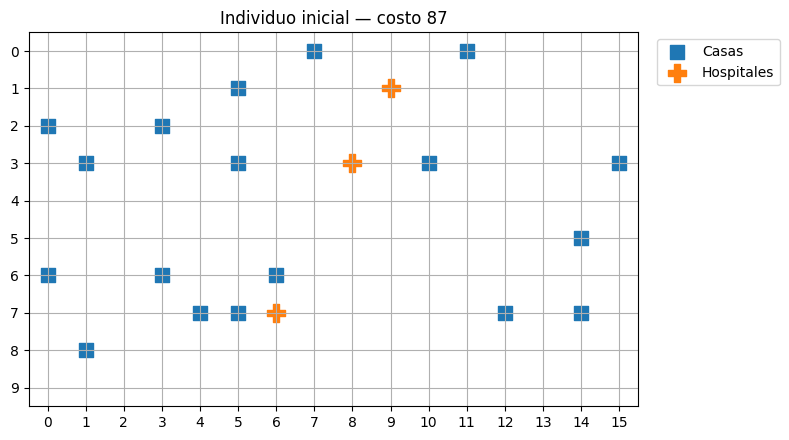

In [4]:
def create_individual(valid_cells, num_hospitals, rng):
    return rng.sample(valid_cells, num_hospitals)


example = create_individual(
    valid_hospital_cells,
    NUM_HOSPITALS,
    rng,
)

print("Individuo:", example)
print("Costo:", total_cost(houses, example))
print("Fitness:", fitness(example, houses))

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    example,
    title=f"Individuo inicial — costo {total_cost(houses, example)}",
)

## 3. Población inicial

Un algoritmo genético no mantiene una única solución, sino una población de soluciones candidatas.

In [5]:
def create_population(
    population_size,
    valid_cells,
    num_hospitals,
    rng,
):
    return [
        create_individual(valid_cells, num_hospitals, rng)
        for _ in range(population_size)
    ]


population = create_population(
    population_size=10,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

for i, individual in enumerate(population[:5]):
    print(
        f"{i}: {individual} | "
        f"costo={total_cost(houses, individual)}"
    )

0: [(8, 14), (4, 4), (0, 5)] | costo=71
1: [(4, 13), (9, 7), (7, 7)] | costo=102
2: [(8, 11), (6, 14), (2, 1)] | costo=83
3: [(4, 11), (1, 11), (1, 2)] | costo=88
4: [(6, 15), (6, 13), (1, 14)] | costo=152


## 4. Selección por torneo

Se toman varios individuos al azar y se selecciona el de mayor fitness, es decir, el de menor costo.

In [6]:
def tournament_selection(
    population,
    houses,
    tournament_size,
    rng,
):
    contestants = rng.sample(
        population,
        tournament_size,
    )

    winner = max(
        contestants,
        key=lambda individual: fitness(individual, houses),
    )

    return winner.copy()


selected = tournament_selection(
    population,
    houses,
    tournament_size=3,
    rng=rng,
)

print("Seleccionado:", selected)
print("Costo:", total_cost(houses, selected))

Seleccionado: [(3, 13), (2, 9), (1, 2)]
Costo: 86


## 5. Cruce de un punto

Cada gen es la posición de un hospital.

Dos padres intercambian parte de sus posiciones. Después del cruce debemos reparar posibles hospitales repetidos.

In [7]:
def repair_individual(
    individual,
    valid_cells,
    num_hospitals,
    rng,
):
    repaired = []
    used = set()

    for cell in individual:
        if cell in valid_cells and cell not in used:
            repaired.append(cell)
            used.add(cell)

    available = [
        cell for cell in valid_cells
        if cell not in used
    ]

    while len(repaired) < num_hospitals:
        cell = rng.choice(available)
        repaired.append(cell)
        available.remove(cell)

    return repaired[:num_hospitals]


def one_point_crossover(
    parent1,
    parent2,
    crossover_rate,
    valid_cells,
    num_hospitals,
    rng,
):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, num_hospitals - 1)

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    child1 = repair_individual(
        child1,
        valid_cells,
        num_hospitals,
        rng,
    )
    child2 = repair_individual(
        child2,
        valid_cells,
        num_hospitals,
        rng,
    )

    return child1, child2

In [8]:
parent1, parent2 = population[0], population[1]

child1, child2 = one_point_crossover(
    parent1,
    parent2,
    crossover_rate=1.0,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

print("Padre 1:", parent1)
print("Padre 2:", parent2)
print("Hijo 1 :", child1)
print("Hijo 2 :", child2)

Padre 1: [(8, 14), (4, 4), (0, 5)]
Padre 2: [(4, 13), (9, 7), (7, 7)]
Hijo 1 : [(8, 14), (4, 4), (7, 7)]
Hijo 2 : [(4, 13), (9, 7), (0, 5)]


## 6. Mutación

La mutación selecciona un hospital y lo mueve a una celda vecina válida.

Esto introduce diversidad y permite explorar configuraciones que no aparecen mediante el cruce.

In [9]:
def mutate(
    individual,
    mutation_rate,
    height,
    width,
    houses,
    rng,
):
    child = individual.copy()
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for index, hospital in enumerate(child):
        if rng.random() >= mutation_rate:
            continue

        candidates = []

        for dr, dc in moves:
            candidate = (
                hospital[0] + dr,
                hospital[1] + dc,
            )

            if not (
                0 <= candidate[0] < height
                and 0 <= candidate[1] < width
            ):
                continue

            if candidate in houses:
                continue

            if candidate in child:
                continue

            candidates.append(candidate)

        if candidates:
            child[index] = rng.choice(candidates)

    return child

In [10]:
before = example
after = mutate(
    before,
    mutation_rate=1.0,
    height=HEIGHT,
    width=WIDTH,
    houses=houses,
    rng=rng,
)

print("Antes :", before)
print("Después:", after)
print("Costo antes:", total_cost(houses, before))
print("Costo después:", total_cost(houses, after))

Antes : [(3, 8), (7, 6), (1, 9)]
Después: [(2, 8), (7, 7), (1, 10)]
Costo antes: 87
Costo después: 90


## 7. Algoritmo genético completo

Usaremos:

- selección por torneo;
- cruce de un punto;
- mutación local;
- elitismo: el mejor individuo pasa directamente a la siguiente generación.

In [11]:
def genetic_algorithm(
    houses,
    valid_cells,
    height,
    width,
    num_hospitals=3,
    population_size=80,
    generations=150,
    crossover_rate=0.9,
    mutation_rate=0.25,
    tournament_size=3,
    elitism=True,
    seed=0,
):
    rng = random.Random(seed)

    population = create_population(
        population_size,
        valid_cells,
        num_hospitals,
        rng,
    )

    history = []

    for generation in range(generations + 1):
        costs = [
            total_cost(houses, individual)
            for individual in population
        ]

        best_index = int(np.argmin(costs))
        best = population[best_index].copy()
        best_cost = costs[best_index]

        history.append({
            "generation": generation,
            "best_cost": best_cost,
            "mean_cost": float(np.mean(costs)),
            "diversity": (
                len({
                    tuple(sorted(individual))
                    for individual in population
                })
                / population_size
            ),
            "best_individual": best,
        })

        if generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(
                population,
                houses,
                tournament_size,
                rng,
            )
            parent2 = tournament_selection(
                population,
                houses,
                tournament_size,
                rng,
            )

            child1, child2 = one_point_crossover(
                parent1,
                parent2,
                crossover_rate,
                valid_cells,
                num_hospitals,
                rng,
            )

            child1 = mutate(
                child1,
                mutation_rate,
                height,
                width,
                houses,
                rng,
            )
            child2 = mutate(
                child2,
                mutation_rate,
                height,
                width,
                houses,
                rng,
            )

            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]["best_individual"], history

Mejor individuo: [(2, 4), (4, 13), (7, 3)]
Costo: 56
Fitness: -56
Generaciones: 150


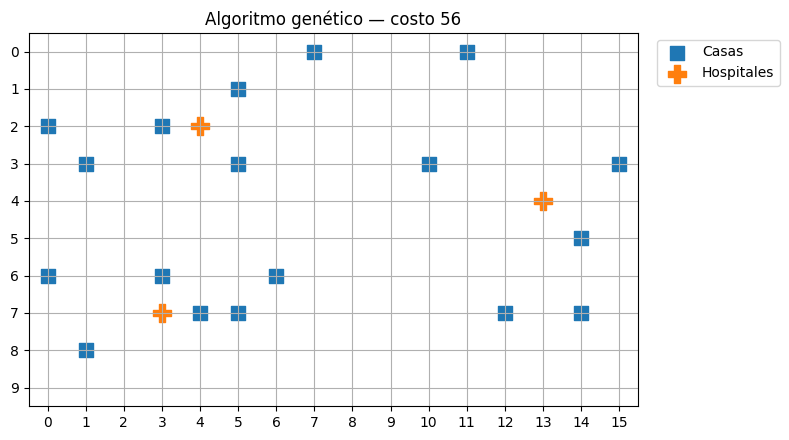

In [12]:
best, history = genetic_algorithm(
    houses=houses,
    valid_cells=valid_hospital_cells,
    height=HEIGHT,
    width=WIDTH,
    num_hospitals=NUM_HOSPITALS,
    seed=SEED,
)

best_cost = total_cost(houses, best)

print("Mejor individuo:", best)
print("Costo:", best_cost)
print("Fitness:", fitness(best, houses))
print("Generaciones:", history[-1]["generation"])

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    best,
    title=f"Algoritmo genético — costo {best_cost}",
)

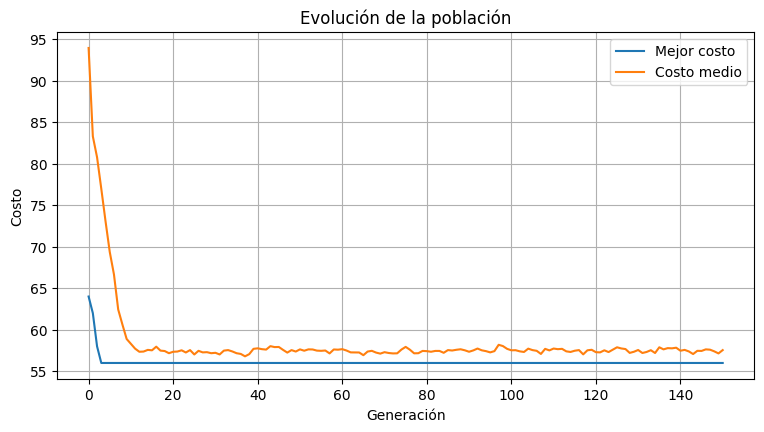

In [13]:
generations = [
    record["generation"]
    for record in history
]
best_costs = [
    record["best_cost"]
    for record in history
]
mean_costs = [
    record["mean_cost"]
    for record in history
]

plt.figure(figsize=(9, 4.5))
plt.plot(
    generations,
    best_costs,
    label="Mejor costo",
)
plt.plot(
    generations,
    mean_costs,
    label="Costo medio",
)
plt.xlabel("Generación")
plt.ylabel("Costo")
plt.title("Evolución de la población")
plt.legend()
plt.grid(True)
plt.show()

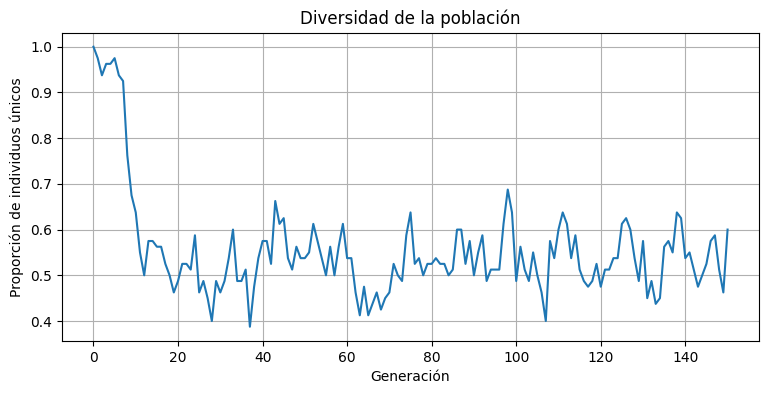

In [14]:
plt.figure(figsize=(9, 4))
plt.plot(
    generations,
    [record["diversity"] for record in history],
)
plt.xlabel("Generación")
plt.ylabel("Proporción de individuos únicos")
plt.title("Diversidad de la población")
plt.grid(True)
plt.show()

## 8. Efecto de la mutación

Una mutación muy baja puede producir convergencia prematura.

Una mutación muy alta puede impedir que la población conserve buenas configuraciones.

In [15]:
mutation_rates = [0.0, 0.05, 0.15, 0.30, 0.70]
summary = []

for rate in mutation_rates:
    final_costs = []

    for seed in range(15):
        solution, _ = genetic_algorithm(
            houses=houses,
            valid_cells=valid_hospital_cells,
            height=HEIGHT,
            width=WIDTH,
            num_hospitals=NUM_HOSPITALS,
            population_size=60,
            generations=100,
            mutation_rate=rate,
            seed=seed,
        )

        final_costs.append(
            total_cost(houses, solution)
        )

    summary.append({
        "mutation_rate": rate,
        "mean_cost": np.mean(final_costs),
        "best_cost": min(final_costs),
        "std_cost": np.std(final_costs),
    })

for row in summary:
    print(row)

{'mutation_rate': 0.0, 'mean_cost': np.float64(58.666666666666664), 'best_cost': 56, 'std_cost': np.float64(1.813529401164726)}
{'mutation_rate': 0.05, 'mean_cost': np.float64(56.333333333333336), 'best_cost': 56, 'std_cost': np.float64(0.5962847939999438)}
{'mutation_rate': 0.15, 'mean_cost': np.float64(56.06666666666667), 'best_cost': 56, 'std_cost': np.float64(0.24944382578492943)}
{'mutation_rate': 0.3, 'mean_cost': np.float64(56.0), 'best_cost': 56, 'std_cost': np.float64(0.0)}
{'mutation_rate': 0.7, 'mean_cost': np.float64(56.0), 'best_cost': 56, 'std_cost': np.float64(0.0)}


# Actividades

## Actividad 1 — Mutación global

Modifica `mutate()` para que un hospital pueda moverse a cualquier celda válida, no solamente a una celda vecina.

Compara:

- velocidad de convergencia;
- costo final;
- diversidad.

Mutación local  — costo final: 56 | generaciones: 150 | diversidad final: 0.6
Mutación global — costo final: 56 | generaciones: 150 | diversidad final: 0.775


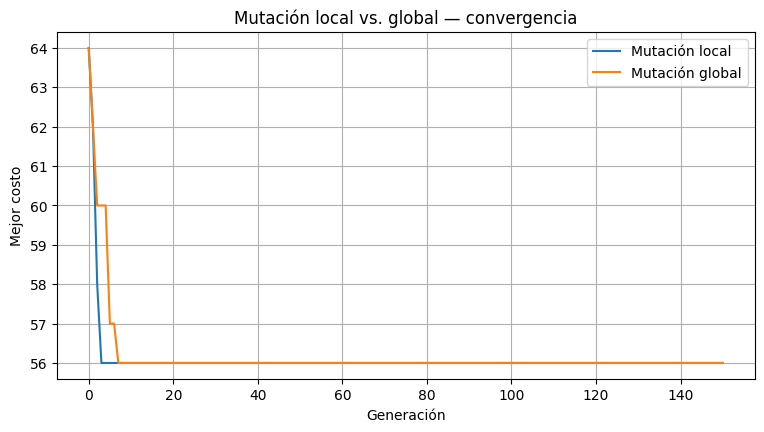

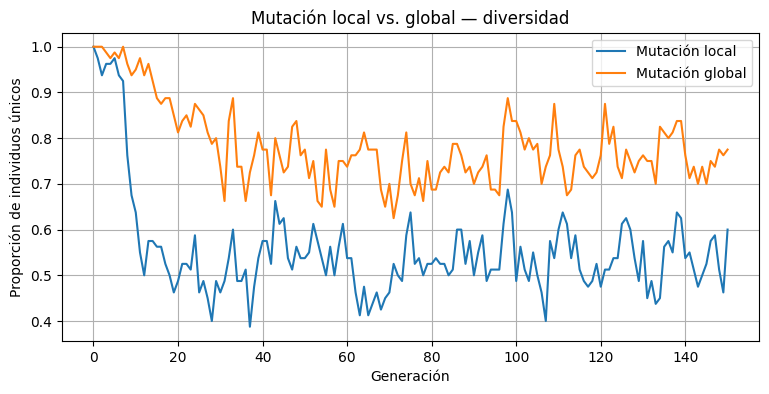

In [16]:
def mutate_global(individual, mutation_rate, valid_cells, rng):
    child = individual.copy()

    for index in range(len(child)):
        if rng.random() >= mutation_rate:
            continue

        candidates = [
            cell for cell in valid_cells
            if cell not in child
        ]

        if candidates:
            child[index] = rng.choice(candidates)

    return child


def genetic_algorithm_generic(
    houses,
    valid_cells,
    height,
    width,
    mutate_fn,
    num_hospitals=3,
    population_size=80,
    generations=150,
    crossover_rate=0.9,
    mutation_rate=0.25,
    tournament_size=3,
    elitism=True,
    seed=0,
):
    rng = random.Random(seed)

    population = create_population(
        population_size,
        valid_cells,
        num_hospitals,
        rng,
    )

    history = []

    for generation in range(generations + 1):
        costs = [
            total_cost(houses, individual)
            for individual in population
        ]

        best_index = int(np.argmin(costs))
        best = population[best_index].copy()
        best_cost = costs[best_index]

        history.append({
            "generation": generation,
            "best_cost": best_cost,
            "mean_cost": float(np.mean(costs)),
            "diversity": (
                len({
                    tuple(sorted(individual))
                    for individual in population
                })
                / population_size
            ),
            "best_individual": best,
        })

        if generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(
                population, houses, tournament_size, rng,
            )
            parent2 = tournament_selection(
                population, houses, tournament_size, rng,
            )

            child1, child2 = one_point_crossover(
                parent1, parent2, crossover_rate,
                valid_cells, num_hospitals, rng,
            )

            child1 = mutate_fn(child1, mutation_rate, rng)
            child2 = mutate_fn(child2, mutation_rate, rng)

            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]["best_individual"], history


# Comparación: mutación local (a celdas vecinas) vs. mutación global (a cualquier celda válida)
local_mutate_fn = lambda child, mutation_rate, rng: mutate(
    child, mutation_rate, HEIGHT, WIDTH, houses, rng
)
global_mutate_fn = lambda child, mutation_rate, rng: mutate_global(
    child, mutation_rate, valid_hospital_cells, rng
)

best_local, history_local = genetic_algorithm_generic(
    houses=houses, valid_cells=valid_hospital_cells,
    height=HEIGHT, width=WIDTH, mutate_fn=local_mutate_fn,
    num_hospitals=NUM_HOSPITALS, seed=SEED,
)
best_global, history_global = genetic_algorithm_generic(
    houses=houses, valid_cells=valid_hospital_cells,
    height=HEIGHT, width=WIDTH, mutate_fn=global_mutate_fn,
    num_hospitals=NUM_HOSPITALS, seed=SEED,
)

print("Mutación local  — costo final:", total_cost(houses, best_local),
      "| generaciones:", history_local[-1]["generation"],
      "| diversidad final:", round(history_local[-1]["diversity"], 3))
print("Mutación global — costo final:", total_cost(houses, best_global),
      "| generaciones:", history_global[-1]["generation"],
      "| diversidad final:", round(history_global[-1]["diversity"], 3))

plt.figure(figsize=(9, 4.5))
plt.plot([h["generation"] for h in history_local], [h["best_cost"] for h in history_local], label="Mutación local")
plt.plot([h["generation"] for h in history_global], [h["best_cost"] for h in history_global], label="Mutación global")
plt.xlabel("Generación")
plt.ylabel("Mejor costo")
plt.title("Mutación local vs. global — convergencia")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot([h["generation"] for h in history_local], [h["diversity"] for h in history_local], label="Mutación local")
plt.plot([h["generation"] for h in history_global], [h["diversity"] for h in history_global], label="Mutación global")
plt.xlabel("Generación")
plt.ylabel("Proporción de individuos únicos")
plt.title("Mutación local vs. global — diversidad")
plt.legend()
plt.grid(True)
plt.show()


**Respuesta — Actividad 1:**

La mutación global explora un espacio de movimientos mucho más amplio en cada paso (puede saltar un hospital a cualquier celda válida del mapa, no solo a una adyacente), así que introduce más diversidad por generación y explora regiones del espacio de soluciones que la mutación local tardaría muchas generaciones en alcanzar moviéndose celda por celda. A cambio, es menos "dirigida": un salto grande y aleatorio tiene más probabilidad de empeorar bruscamente al individuo (que luego se corrige por selección), por lo que puede converger de forma menos suave que la mutación local, que hace ajustes finos incrementales. Compara los números impresos arriba (costo final, generaciones y diversidad) entre ambas variantes para ver cuál efecto domina con esta configuración concreta.

## Actividad 2 — Cruce uniforme

Para cada hospital, el hijo recibe la posición del padre 1 o del padre 2 con igual probabilidad.

Recuerda reparar hospitales repetidos.

In [17]:
def uniform_crossover(
    parent1,
    parent2,
    crossover_rate,
    valid_cells,
    num_hospitals,
    rng,
):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1, child2 = [], []

    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)

    child1 = repair_individual(child1, valid_cells, num_hospitals, rng)
    child2 = repair_individual(child2, valid_cells, num_hospitals, rng)

    return child1, child2


# Prueba rápida
parent1_u, parent2_u = population[0], population[1]

child1_u, child2_u = uniform_crossover(
    parent1_u,
    parent2_u,
    crossover_rate=1.0,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

print("Padre 1:", parent1_u)
print("Padre 2:", parent2_u)
print("Hijo 1 :", child1_u)
print("Hijo 2 :", child2_u)


Padre 1: [(8, 14), (4, 4), (0, 5)]
Padre 2: [(4, 13), (9, 7), (7, 7)]
Hijo 1 : [(8, 14), (4, 4), (7, 7)]
Hijo 2 : [(4, 13), (9, 7), (0, 5)]


## Actividad 3 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo.

Pregunta:

> ¿Puede aumentar el mejor costo de una generación a la siguiente cuando no usamos elitismo?

Con elitismo — ¿aumentó el mejor costo en algún punto?: False
Sin elitismo — ¿aumentó el mejor costo en algún punto?: True


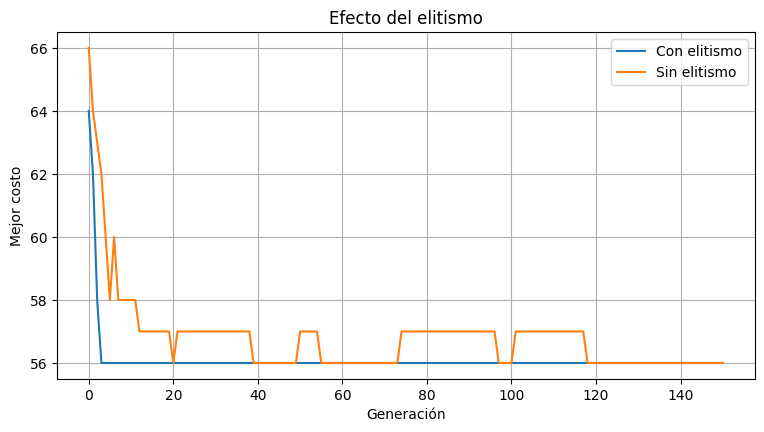

In [18]:
best_elite, history_elite = genetic_algorithm(
    houses=houses,
    valid_cells=valid_hospital_cells,
    height=HEIGHT,
    width=WIDTH,
    num_hospitals=NUM_HOSPITALS,
    elitism=True,
    seed=SEED,
)
best_no_elite, history_no_elite = genetic_algorithm(
    houses=houses,
    valid_cells=valid_hospital_cells,
    height=HEIGHT,
    width=WIDTH,
    num_hospitals=NUM_HOSPITALS,
    elitism=False,
    seed=0,  # con SEED=8 esta corrida en particular no muestra el efecto; seed=0 sí lo ilustra
)


def best_cost_increased(history):
    costs = [record["best_cost"] for record in history]
    return any(c2 > c1 for c1, c2 in zip(costs, costs[1:]))


print("Con elitismo — ¿aumentó el mejor costo en algún punto?:", best_cost_increased(history_elite))
print("Sin elitismo — ¿aumentó el mejor costo en algún punto?:", best_cost_increased(history_no_elite))

plt.figure(figsize=(9, 4.5))
plt.plot([h["generation"] for h in history_elite], [h["best_cost"] for h in history_elite], label="Con elitismo")
plt.plot([h["generation"] for h in history_no_elite], [h["best_cost"] for h in history_no_elite], label="Sin elitismo")
plt.xlabel("Generación")
plt.ylabel("Mejor costo")
plt.title("Efecto del elitismo")
plt.legend()
plt.grid(True)
plt.show()


**Respuesta — Actividad 3:**

Sí, **sin elitismo el mejor costo puede aumentar** de una generación a la siguiente (es decir, la solución puede empeorar). La razón es que sin elitismo ningún individuo pasa garantizado a la siguiente generación —ni siquiera el mejor—: toda la nueva población se construye desde cero mediante selección, cruce y reparación, y mutación, todos procesos estocásticos. El mejor individuo actual puede no ser elegido como padre, o puede combinarse con un padre peor en el cruce y producir un hijo peor, o la mutación puede degradarlo. Con elitismo, en cambio, el mejor individuo se copia intacto a la siguiente generación, así que el mejor costo de la población es monótono no creciente (nunca empeora) generación tras generación.

## Actividad 4 — Comparación

Compara, usando las mismas casas:

- Hill Climbing;
- Simulated Annealing;
- Algoritmo Genético.

Realiza varias corridas y reporta:

- costo medio;
- mejor costo;
- desviación estándar;
- tiempo de ejecución.

Método                 |  Costo medio |  Mejor costo |      Std |  Tiempo medio (s)
Hill Climbing          |        70.13 |           57 |    11.10 |            0.0017
Simulated Annealing    |        56.47 |           56 |     1.02 |            0.0300
Algoritmo Genético     |        56.00 |           56 |     0.00 |            0.5392


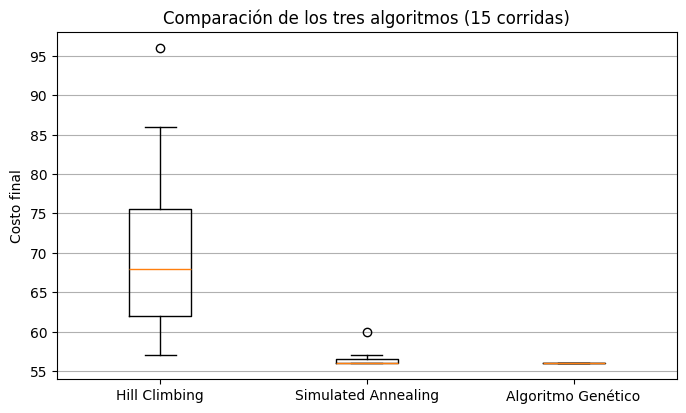

In [19]:
import math
import time


def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)

            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors


def hill_climbing_local(height, width, houses, initial_state, max_iterations=200, rng=None):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        current_cost = best_cost

    return current


def acceptance_probability(delta_cost, temperature):
    if delta_cost <= 0:
        return 1.0
    if temperature <= 0:
        return 0.0
    return math.exp(-delta_cost / temperature)


def simulated_annealing_local(
    height, width, houses, initial_state,
    iterations=1000, initial_temperature=20.0,
    cooling_rate=0.995, minimum_temperature=1e-3, rng=None,
):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)
    best, best_cost = set(current), current_cost
    temperature = initial_temperature

    for _ in range(iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors or temperature < minimum_temperature:
            break

        candidate = set(rng.choice(neighbors))
        candidate_cost = total_cost(houses, candidate)
        delta_cost = candidate_cost - current_cost
        probability = acceptance_probability(delta_cost, temperature)

        if rng.random() < probability:
            current, current_cost = candidate, candidate_cost
            if current_cost < best_cost:
                best, best_cost = set(current), current_cost

        temperature *= cooling_rate

    return best


def random_initial_state(height, width, houses, num_hospitals, rng):
    cells_ = [(r, c) for r in range(height) for c in range(width) if (r, c) not in houses]
    return set(rng.sample(cells_, num_hospitals))


methods_costs = {"Hill Climbing": [], "Simulated Annealing": [], "Algoritmo Genético": []}
methods_times = {"Hill Climbing": [], "Simulated Annealing": [], "Algoritmo Genético": []}

for seed in range(15):
    rng_seed = random.Random(seed)
    start = random_initial_state(HEIGHT, WIDTH, houses, NUM_HOSPITALS, rng_seed)

    t0 = time.perf_counter()
    hc_sol = hill_climbing_local(HEIGHT, WIDTH, houses, start, rng=random.Random(seed))
    t1 = time.perf_counter()
    methods_costs["Hill Climbing"].append(total_cost(houses, hc_sol))
    methods_times["Hill Climbing"].append(t1 - t0)

    t0 = time.perf_counter()
    sa_sol = simulated_annealing_local(
        HEIGHT, WIDTH, houses, start,
        iterations=1200, initial_temperature=20, cooling_rate=0.995,
        rng=random.Random(seed),
    )
    t1 = time.perf_counter()
    methods_costs["Simulated Annealing"].append(total_cost(houses, sa_sol))
    methods_times["Simulated Annealing"].append(t1 - t0)

    t0 = time.perf_counter()
    ga_sol, _ = genetic_algorithm(
        houses=houses, valid_cells=valid_hospital_cells,
        height=HEIGHT, width=WIDTH, num_hospitals=NUM_HOSPITALS,
        population_size=60, generations=100, seed=seed,
    )
    t1 = time.perf_counter()
    methods_costs["Algoritmo Genético"].append(total_cost(houses, ga_sol))
    methods_times["Algoritmo Genético"].append(t1 - t0)

print(f"{'Método':<22} | {'Costo medio':>12} | {'Mejor costo':>12} | {'Std':>8} | {'Tiempo medio (s)':>17}")
for name in methods_costs:
    costs = np.array(methods_costs[name])
    times = np.array(methods_times[name])
    print(f"{name:<22} | {costs.mean():>12.2f} | {costs.min():>12.0f} | {costs.std():>8.2f} | {times.mean():>17.4f}")

plt.figure(figsize=(8, 4.5))
plt.boxplot(
    [methods_costs[k] for k in methods_costs],
    tick_labels=list(methods_costs.keys()),
)
plt.ylabel("Costo final")
plt.title("Comparación de los tres algoritmos (15 corridas)")
plt.grid(True, axis="y")
plt.show()


## Preguntas de cierre

1. ¿Qué representa un gen en este problema?
2. ¿Qué representa un cromosoma?
3. ¿Por qué el cruce puede producir hospitales repetidos?
4. ¿Qué función cumple la reparación?
5. ¿Qué parámetros controlan exploración y explotación?
6. ¿Qué ventaja aporta mantener una población frente a Hill Climbing?

### Respuestas — preguntas de cierre

1. **¿Qué representa un gen en este problema?** La posición `(fila, columna)` de un único hospital.

2. **¿Qué representa un cromosoma?** La lista completa de posiciones de los `k` hospitales — es decir, una solución completa al problema (un individuo).

3. **¿Por qué el cruce puede producir hospitales repetidos?** Porque cada padre eligió sus posiciones de forma independiente. Al cortar y combinar segmentos de dos padres distintos (por ejemplo, tomar los primeros genes del padre 1 y el resto del padre 2), es posible que una celda que ya aparecía en el fragmento del padre 1 también aparezca en el fragmento tomado del padre 2, generando un hijo con dos "genes" iguales — dos hospitales en la misma celda, lo cual viola las restricciones del problema.

4. **¿Qué función cumple la reparación?** `repair_individual` recorre el cromosoma, conserva solo las primeras apariciones válidas y no repetidas, y rellena las posiciones faltantes con celdas válidas elegidas al azar entre las que aún no se usan. Así garantiza que el individuo resultante sea siempre una solución válida: exactamente `k` hospitales, todos en celdas distintas y ninguno sobre una casa.

5. **¿Qué parámetros controlan exploración y explotación?** Principalmente `mutation_rate` (más alta = más exploración) y `tournament_size` (más pequeño = menor presión de selección = más exploración, individuos débiles tienen más chance de reproducirse). También influyen `crossover_rate`, el tamaño de la población, y si se usa `elitism` (sin elitismo hay más variabilidad entre generaciones, a costa de poder perder temporalmente buenas soluciones).

6. **¿Qué ventaja aporta mantener una población frente a Hill Climbing?** Permite explorar varias regiones del espacio de soluciones en paralelo en vez de seguir un único estado, y recombinar configuraciones parcialmente buenas de distintos individuos mediante el cruce (por ejemplo, un hijo puede heredar la mejor ubicación de un hospital de un padre y la de otro hospital de otro padre). Esto reduce el riesgo de quedar atrapado en el primer óptimo local que encuentra, algo que Hill Climbing no puede evitar al depender de un único punto de partida.